The purpose of this notebook is to test a method to globally fit the aggregated Am241 calibration data while constraining the widths of the peaks such that they follow expected Fano noise behavior. The spectrum is aggregated across Pixels 9, 10, and 11 from each ASIC 0, 1, 2, 3. Pixel 8 is excluded because it physically touches the guard ring and is thus more susceptible to noise.

Last updated 2025-11-02 by Niharika Godbole

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.signal import convolve
from scipy.optimize import least_squares

In [2]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data")

In [7]:
def exp_background(x, amp, tau, c):
    """Function to model an exponentially decaying background."""
    return amp * np.exp(-x / tau) + c


def gaussian(x, amp, mu, sigma):
    """Function to model Gaussian peak."""
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def crystal_ball_phys(x, amp, mu, sigma, alpha, n):
    """Function to model Crystal Ball peak. This type of distribution accounts for a Gaussian peak + power-law tailing."""
    t = (x - mu) / sigma
    abs_alpha = np.abs(alpha)
    y = np.zeros_like(x)
    
    # Gaussian core. 
    mask_core = t > -abs_alpha
    y[mask_core] = np.exp(-0.5 * t[mask_core] ** 2)

    # Power-law tail. 
    mask_tail = ~mask_core
    if np.any(mask_tail):
        A = (n / abs_alpha) ** n * np.exp(-0.5 * abs_alpha ** 2)
        B = n / abs_alpha - abs_alpha
        # Avoid negative base for fractional powers. 
        safe_term = np.clip(B - t[mask_tail], 1e-12, None)
        y[mask_tail] = A * safe_term ** (-n)

    return amp * y


def fano_sigma(mu, enc):
    """Function to model the energy resolution (Fano + electronic noise contributions) as a function of energy."""
    Eps = 4.43  # [eV] # Average energy to create an electron hole pair in CdTe. 
    F = 0.15    # Fano factor for CdTe. 
    mu = np.asarray(mu)
    sigma_keV = np.sqrt((Eps * F * mu * 1000.0) + (Eps * enc) ** 2) / 1000.0
    
    return sigma_keV


def residuals(params, x, y, config, weights=None):
    """Compute the residuals for the least-squares function."""
    r = am241_composite_model(x, params, config) - y
    if weights is not None:
        r = r * weights
    
    return r


def am241_composite_model(x, params, config):
    idx = 0
    y = np.zeros_like(x)

    # Background
    amp_bg, tau_bg, c_bg = params[idx:idx+3]
    idx += 3
    y += exp_background(x, amp_bg, tau_bg, c_bg)

    # ENC parameter for linked sigmas
    enc = None
    if config.get("link_sigma", False):
        enc = params[idx]
        idx += 1

    # Gaussians
    for _ in range(config.get("n_gauss", 0)):
        amp = params[idx]
        mu = params[idx+1]
        if config.get("link_sigma", False):
            sigma = fano_sigma(mu, enc)
            idx += 2
        else:
            sigma = params[idx+2]
            idx += 3
        y += gaussian(x, amp, mu, sigma)

    # Crystal Balls
    for _ in range(config.get("n_cb", 0)):
        amp = params[idx]
        mu = params[idx+1]
        alpha = params[idx+2]
        n = params[idx+3]
        if config.get("link_sigma", False):
            sigma = fano_sigma(mu, enc)
            idx += 4
        else:
            sigma = params[idx+4]
            idx += 5
        y += crystal_ball_phys(x, amp, mu, sigma, alpha, n)

    return y


def am241_print_fit_summary(p0, fitted, config):
    """
    Comprehensive comparison between guessed and fitted parameters.
    Includes:
      - Background parameters
      - ENC (linked sigma)
      - Each Gaussian and Crystal Ball with (A, mu, sigma, sigma / mu, alpha, n)
    """

    bg_guess = p0[0:3]
    bg_fit   = fitted[0:3]

    print("                      FIT SUMMARY"                         )
    print("Background parameters:")
    print(f"           First guess      Fit res")
    print(f"  amp_bg : {bg_guess[0]}    {bg_fit[0]}")
    print(f"  tau_bg : {bg_guess[1]}    {bg_fit[1]}")
    print(f"  const  : {bg_guess[2]}    {bg_fit[2]}")
    print("----------------------------------------------------------")

    idx0 = idx1 = 3
    enc_guess = p0[idx0]
    enc_fit   = fitted[idx1]
    idx0 += 1
    idx1 += 1

    print(f"ENC (linked sigma): {enc_guess}  {enc_fit} e- RMS")
    print("----------------------------------------------------------")

    header = (
        f"{'Type'}{'#'}"
        f"{'A_guess'}{'A_fit'}"
        f"{'mu_guess'}{'mu_fit'}"
        f"{'sigma_fit'}{'sigma/mu (%)'}"
        f"{'alpha_fit'}{'n_fit'}"
    )
    print(header)
    print("-" * len(header))

    # Define the Gaussians. 
    for i in range(config.get("n_gauss", 0)):
        amp_g, mu_g = p0[idx0:idx0+2]
        amp_f, mu_f = fitted[idx1:idx1+2]
        sigma_f = fano_sigma(mu_f, enc_fit)
        res_pct = 100.0 * sigma_f / mu_f
        print(
            f"{'Gaussian'}{i+1}"
            f"{amp_g}{amp_f}"
            f"{mu_g}{mu_f}"
            f"{sigma_f}{res_pct}"
            f"{'--'}{'--'}"
        )
        idx0 += 2
        idx1 += 2

    # Define the Crystal Balls. 
    for i in range(config.get("n_cb", 0)):
        amp_g, mu_g, alpha_g, n_g = p0[idx0:idx0+4]
        amp_f, mu_f, alpha_f, n_f = fitted[idx1:idx1+4]
        sigma_f = fano_sigma(mu_f, enc_fit)
        res_pct = 100.0 * sigma_f / mu_f
        print(
            f"{'C.Ball'}{i+1}"
            f"{amp_g}{amp_f}"
            f"{mu_g}{mu_f}"
            f"{sigma_f}{res_pct}"
            f"{alpha_f}{n_f}"
        )
        idx0 += 4
        idx1 += 4

    print("-" * len(header))
    print(f"Fitted ENC = {enc_fit} e- RMS")

Text(0, 0.5, 'Counts')

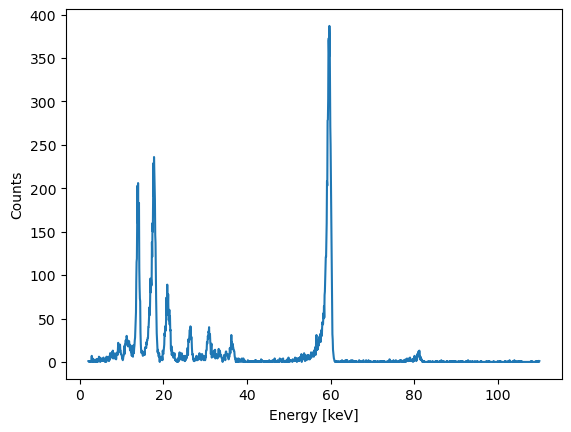

In [14]:
#Read the calibrated aggregated spectrum
data = np.load(data_dir / 'aggregated_am241_data_1kevto110kev_spix_single_events_bl_sub.npz')

# Plot to check. 
plt.plot(data['energy'], data['flux'])
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

0 .......
1 .......
2 .......
3 .......
4 .......
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.5894e+06                                    1.55e+06    
       1              2         1.0988e+06      3.49e+06       4.02e+03       3.85e+05    
       2              3         2.5863e+05      8.40e+05       2.15e+03       9.56e+04    
       3              4         5.7406e+04      2.01e+05       1.10e+03       2.37e+04    
       4              5         1.1743e+04      4.57e+04       5.49e+02       5.75e+03    
       5              6         2.3283e+03      9.41e+03       2.57e+02       1.29e+03    
       6              7         1.1056e+03      1.22e+03       7.42e+01       5.24e+02    
       7              8         8.0038e+02      3.05e+02       2.80e+01       3.03e+02    
       8              9         6.3068e+02      1.70e+02       2.20e+01       1.66e+02    
       9             11         5.5593e+

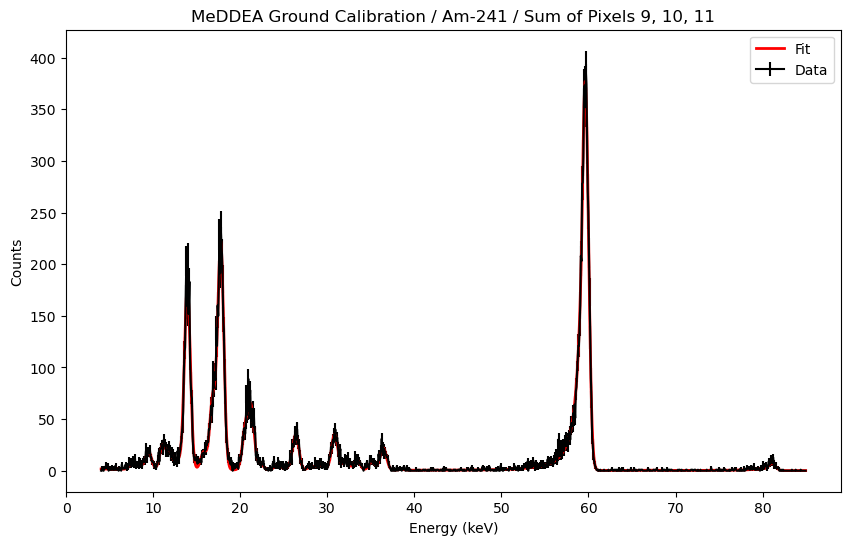

In [ ]:
# Perform the fit. 

E_cor = data['energy']
# select energy range for fit.
pipo = np.where((E_cor>4)&(E_cor<85))

x = E_cor[pipo]
y = data['flux'][pipo]

# Initial guess parameters. 
mus_gauss = [
             7.5,    # 
             8.05,   # 
             9.5,    # 
             10.55,  # 
             11.48,  # Am-241 line
             12.6,   # Am-241 line
             13.852, # Am-241 line
             15.876, # Am-241 line
             16.8,   # 
             17.75,  # Am-241 line
             20.8,   # 
             21.16,  # Am-241 line
             22.9,   # 
             23.2,   # 
             25.5,   # 
             26.1,   # 
             26.3446,# Am-241 line
             27.5,   # 
             28.6,   # 
             29.5,   # 
             31.0,   # 
             32.5,   # Am-241 line
             33.1963,# Am-241 line
             35.1,   # 
             59.54-23.108, # CdTe escape line
             38.55,  # 
             43.66   # weighted average, Am-241 line
             ]
 
amps_gauss = [
              290.,
              400,
              800.,
              1070,
              850.,
              600,
              6200,
              640,
              1900,
              7200,
              2200,
              200,
              320,
              300.,
              100.,
              204,
              1310,
              170,
              260,
              180,
              1131,
              480,
              331,
              335, 
              900,
              40.,
              100.]

mus_cb      = [
               53.8, # 
               59.54,# Am-241 line
               67.2, # 
               79.6, # Ba-133 line
               81.0  # Ba-133 line
               ]

amps_cb     = [300, 3000, 32., 40., 300.]
alphas_cb   = [1.0, 1.0, 1.0, 1.0, 1.0]
ns_cb       = [2.5, 2.5, 2.5, 2.5, 2.5]


config = {"background": "exp", "n_gauss": len(mus_gauss), "n_cb": len(mus_cb), "link_sigma": True}

# Initial guesses for the background and ENC. 
p0 = []
p0 += [1, 18, 0.5]
p0 += [70.] # ENC

# Initial guesses for the Gaussians. 
for A, mu in zip(amps_gauss, mus_gauss):
    p0 += [A * 0.8, mu]

# Initial guesses for the CrystalBalls. 
for A, mu, alpha, n in zip(amps_cb, mus_cb, alphas_cb, ns_cb):
    p0 += [A * 0.8, mu, alpha, n]

p0 = np.array(p0)

# Define parameter bounds. 
n_params = len(p0)
lower = -np.inf * np.ones(n_params)
upper = np.inf * np.ones(n_params)

# Bounds for background. 
lower[0] = 0
lower[1] = 10
lower[2] = 0.1
upper[0] = 2
upper[1] = 19
upper[2] = 1.

# Bounds for ENC (positive and realistic). 
lower[3] = 65.
upper[3] = 80.

# Gaussian amplitudes >= 0
first_gauss_amp = 4 # offset in pars after background and ENC.
for i in range(config["n_gauss"]):
    lower[first_gauss_amp + 2*i] = 0.

# Crystal Ball amplitudes, alpha, n bounds
idx_cb_start = first_gauss_amp + 2 * config["n_gauss"]
alpha_min, alpha_max = 0.3, 4.5
n_min, n_max = 0.5, 4.5
for i in range(config["n_cb"]):
    print(i, '.......')
    amp_i = idx_cb_start + 4*i
    alpha_i = amp_i + 2
    n_i = amp_i + 3
    lower[amp_i] = 0.0
    lower[alpha_i], upper[alpha_i] = alpha_min, alpha_max
    lower[n_i], upper[n_i] = n_min, n_max

# Compute weights.
sigma_w = np.sqrt(np.maximum(y, 1.0)) # Poisson weights are 1 / sigma; sigma = sqrt(N).
weights = 1.0 / sigma_w

# Weighted least squares fit. 
res = least_squares(
    residuals,
    p0,
    args=(x, y, config, weights),
    bounds=(lower, upper),
    verbose=2
)

print("\nFit success:", res.success)
print("Message:", res.message)
print("Fitted ENC = e- RMS" % res.x[3])

am241_print_fit_summary(p0, res.x, config)

plt.figure(figsize=(10, 6))
plt.errorbar(x, y, yerr = y**0.5, label="Data", color = 'k')
plt.plot(x, am241_composite_model(x, res.x, config), "-r", lw=2.0, label="Fit")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("MeDDEA Ground Calibration / Am-241 / Sum of Pixels 9, 10, 11")
plt.legend()
plt.show()

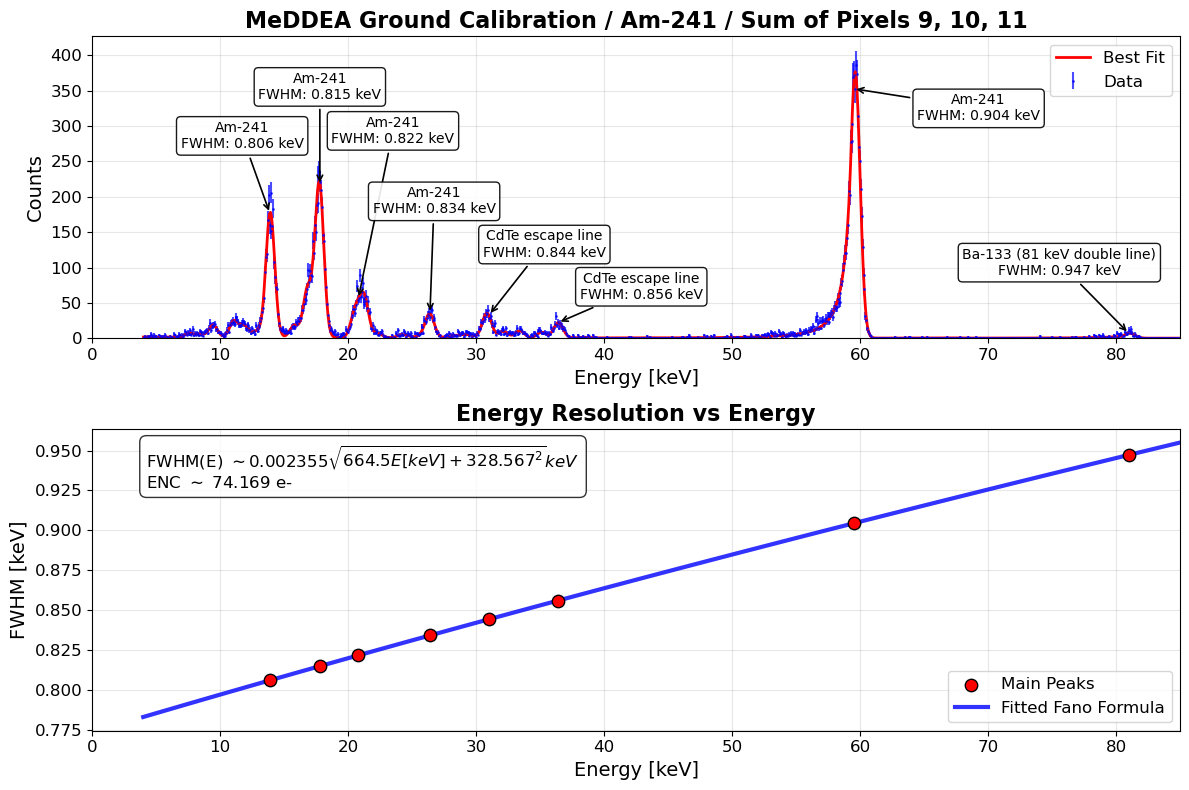


FWHM Summary from Fitted Model (ENC = 74.16870835735499 e-):
Peak Energy FWHM Resolution
Am-241 13.9 0.8061983047548164 5.799987803991485%
Am-241 17.8 0.8150634991694143 4.579008422300081%
Am-241 20.8 0.8218178073732583 3.9510471508329723%
Am-241 26.4 0.8342795555122934 3.16014983148596%
CdTe escape line 31.0 0.8443784171586161 2.723801345672955%
CdTe escape line 36.4 0.8560816040955381 2.351872538724006%
Am-241 59.5 0.9044373495823466 1.520062772407305%
Ba-133 (81 keV double line) 81.0 0.9472283737242512 1.1694177453385817%

Fit Quality:
   chi squared = inf
   DOF = 1048
   Reduced chi squared = inf
   RMS residuals = nan

Comparison with extracted peaks:
Energy 13.9 keV: Extracted=0.806259997594347, Calculated=0.806259997594347 keV
Energy 17.8 keV: Extracted=0.8149641488351571, Calculated=0.8149641488351571 keV
Energy 20.8 keV: Extracted=0.8213153930803372, Calculated=0.8213153930803372 keV
Energy 26.4 keV: Extracted=0.8342329255194175, Calculated=0.8342329255194175 keV
Energy 31.0

C:\Users\ngodbole\AppData\Local\Temp\1\ipykernel_30360\1971150286.py:207: RuntimeWarning: divide by zero encountered in divide
  residuals_norm = (y - model_total) / np.sqrt(y)


In [ ]:
def extract_peak_info(fitted_params, config):
    """
    Extract peak positions and calculate FWHM from fitted parameters.
    Returns a list of (energy, fwhm, amplitude) for significant peaks.
    """
    peaks = []
    
    # Determine the correct starting index based on background type.
    bg_type = config.get("background_type", "exp")
    if bg_type == "enhanced":
        idx = 8 
    elif bg_type == "poly_exp":
        idx = 5 
    else:
        idx = 3
    
    # Get ENC from fitted parameters.
    if config.get("link_sigma", False):
        enc = fitted_params[idx]
        idx += 1
    
    # Extract Gaussian peaks.
    for i in range(config.get("n_gauss", 0)):
        amp = fitted_params[idx]
        mu = fitted_params[idx + 1]
        
        if config.get("link_sigma", False):
            sigma = fano_sigma(mu, enc)
        else:
            sigma = fitted_params[idx + 2]
            idx += 1  # Extra increment for independent sigma.
        
        fwhm = 2.355 * sigma  # Convert sigma to FWHM.
        peaks.append((mu, fwhm, amp, 'Gaussian'))
        idx += 2
    
    # Extract Crystal Ball peaks.
    for i in range(config.get("n_cb", 0)):
        amp = fitted_params[idx]
        mu = fitted_params[idx + 1]
        alpha = fitted_params[idx + 2]
        n = fitted_params[idx + 3]
        
        if config.get("link_sigma", False):
            sigma = fano_sigma(mu, enc)
        else:
            sigma = fitted_params[idx + 4]
            idx += 1  # Extra increment for independent sigma.
        
        fwhm = 2.355 * sigma  # Convert sigma to FWHM.
        peaks.append((mu, fwhm, amp, 'Crystal Ball'))
        idx += 4
    
    return peaks

def calculate_fwhm_from_fitted_enc(energy, fitted_enc):
    """
    Calculate FWHM directly using the fitted ENC and the fano_sigma function.
    All peaks use the same formula, because link_sigma = True. 
    """
    sigma = fano_sigma(energy, fitted_enc)
    fwhm = 2.355 * sigma
    return fwhm

# Extract the fitted ENC.
bg_type = config.get("background_type", "exp")
if bg_type == "enhanced":
    fitted_enc = res.x[8]
elif bg_type == "poly_exp":
    fitted_enc = res.x[5]
else:
    fitted_enc = res.x[3]

# Define the main peaks for annotation.
main_peaks = [
    (13.9, "Am-241"),
    (17.8, "Am-241"),
    (20.8, "Am-241"),
    (26.4, "Am-241"),
    (31.0, "CdTe escape line"),
    (36.4, "CdTe escape line"),
    (59.5, "Am-241"),
    (81.0, "Ba-133 (81 keV double line)")
]

# Calculate FWHM for each peak. 
peak_energies = []
peak_fwhms = []
peak_labels = []

for energy, label in main_peaks:
    fwhm = calculate_fwhm_from_fitted_enc(energy, fitted_enc)
    peak_energies.append(energy)
    peak_fwhms.append(fwhm)
    peak_labels.append(label)

# Create the plots.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Spectrum with fit on axis 1. 
ax1.errorbar(x, y, yerr=np.sqrt(y), label="Data", color='blue', alpha=0.7, 
            markersize=1, fmt='o', capsize=0)
model_total = am241_composite_model(x, res.x, config)
ax1.plot(x, model_total, "-", color='red', lw=2.0, label="Best Fit")

# Manually position the annotations to avoid overlap.
annotation_configs = [
    (-20, 45, 'center', 'bottom'),  # 13.9 keV
    (0, 60, 'center', 'bottom'),    # 17.8 keV  
    (25, 110, 'center', 'bottom'),  # 20.8 keV
    (3, 70, 'center', 'bottom'),    # 26.4 keV
    (40, 40, 'center', 'bottom'),   # 31.0 keV
    (60, 15, 'center', 'bottom'),   # 36.4 keV
    (90, -25, 'center', 'bottom'),  # 59.5 keV
    (-50, 40, 'center', 'bottom'),  # 81.0 keV
]

# Add the annotations for main peaks.
for i, (energy, label) in enumerate(main_peaks):
    # Find peak height in model for annotation.
    peak_idx = np.argmin(np.abs(x - energy))
    if peak_idx < len(model_total):
        peak_height = model_total[peak_idx]
        fwhm = peak_fwhms[i]
        
        # Get positioning config.
        if i < len(annotation_configs):
            x_off, y_off, ha, va = annotation_configs[i]
        else:
            x_off, y_off, ha, va = (0, 30, 'center', 'bottom')
        
        # Create annotation text with FWHM.
        annotation_text = f'{label}\nFWHM: {fwhm:.3f} keV'
        
        # Add annotation.
        ax1.annotate(annotation_text,
                   xy=(energy, peak_height),
                   xytext=(x_off, y_off),
                   textcoords='offset points',
                   ha=ha, va=va,
                   fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.3', 
                            facecolor='white', 
                            alpha=0.9, 
                            edgecolor='black'),
                   arrowprops=dict(arrowstyle='->', 
                                 color='black', 
                                 lw=1.2))

ax1.set_ylabel("Counts", fontsize=14)
ax1.set_xlabel("Energy [keV]", fontsize=14)
ax1.set_ylim(bottom=0)
ax1.set_xlim(0, 85)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title("MeDDEA Ground Calibration / Am-241 / Sum of Pixels 9, 10, 11", 
             fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# FWHM vs Energy on axis 2. 
ax2.scatter(peak_energies, peak_fwhms, color='red', s=80, zorder=5, 
           label='Main Peaks', edgecolor='black')

# Plot Fano resolution curve.
energy_range = np.linspace(4, 85, 100)
fwhm_curve = [calculate_fwhm_from_fitted_enc(E, fitted_enc) for E in energy_range]
ax2.plot(energy_range, fwhm_curve, 'b-', lw=3, label='Fitted Fano Formula', alpha=0.8)

# Optional: Plot Fano limit (statistical noise only, no electronic noise).
fano_limit = []
Eps = 4.43e-3  # eV per e-h pair converted to keV
F = 0.15       # Fano factor
for E in energy_range:
    sigma_stat = np.sqrt(F * E * Eps)
    fwhm_limit = 2.355 * sigma_stat
    fano_limit.append(fwhm_limit)
#ax2.plot(energy_range, fano_limit, 'k--', lw=2, label='Fano Limit', alpha=0.7)

# Add text box with the derived Fano formula.
formula_textbox = rf"FWHM(E) $\sim {2.355/1000}\sqrt{{{4.43*0.15*1000}E [keV] + {4.43*fitted_enc:.3f}^2}} keV$" + f"\nENC $\sim$ {fitted_enc:.3f} e-"

ax2.text(0.05, 0.95, formula_textbox, 
         transform=ax2.transAxes, 
         fontsize=12, 
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax2.set_xlabel("Energy [keV]", fontsize=14)
ax2.set_ylabel("FWHM [keV]", fontsize=14)
ax2.set_xlim(0, 85)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title("Energy Resolution vs Energy", fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print detailed FWHM summary.
print(f"\nFWHM Summary from Fitted Model (ENC = {fitted_enc} e-):")
print(f"{'Peak'} {'Energy'} {'FWHM'} {'Resolution'}")

for energy, fwhm, label in zip(peak_energies, peak_fwhms, peak_labels):
    resolution = (fwhm / energy) * 100
    print(f"{label} {energy} {fwhm} {resolution}%")

# Print fit statistics
residuals_norm = (y - model_total) / np.sqrt(y)
chi_squared = np.sum(residuals_norm**2)
dof = len(x) - len(res.x)
reduced_chi_sq = chi_squared / dof

print(f"\nFit Quality:")
print(f"   chi squared = {chi_squared}")
print(f"   DOF = {dof}")
print(f"   Reduced chi squared = {reduced_chi_sq}")
print(f"   RMS residuals = {np.std(residuals_norm)}")